In [238]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import CubicSpline

J = 1
# constante de acoplamento
h = 0.1
# campo magnético externo
kb = 1
# constante de boltzmman
rnd = np.random.default_rng(seed=1)
# gerador de número aleatórios


# Classe do Model de Ising
class IsingModel:

    def __init__(self, L, T):
        # parametros do modelo
        self.L = L
        self.T = T

        # array com os spins
        self.spins = np.ones((L, L))

        # arrays para guardar evolução das variáveis
        self.energies = []
        self.magnetizations = []

    def calc_ener_spin(self, i, j)->float:
        _ ,viz = self.neighbours(i, j) # Se só tirarmos dois vizinhos para cada spin só vão ser calculádos uma vez se forem sempre os mesmos?
        direita = viz[3]
        baixo = viz[1]
        own = self.spins[i][j]
        energy = -1 * J * own * (self.spins[direita[0]][direita[1]] + self.spins[baixo[0]][baixo[1]])
        return energy

    def calc_ener(self)->float:
        # para não termos de tar a complicar na escolha dos vizinhos podemos calcular todas as interações duas vezes e dividir por dois
        # Ou aquilo que está escrito no calc_ener_spin
        energy = 0
        for i in range(self.L):
            for j in range(self.L):
                energy += self.calc_ener_spin(i, j)
        energy += -1 * h * np.sum(self.spins)

        return energy

    def calc_mag(self)->float:
        # calcular a magnetização por spin do sistema
        M = J * np.sum(self.spins)
        mag = M / self.L**2
        return mag
    
    def flip(self, i, j)->None:
        self.spins[i][j] *= -1 
    
    def iter_monte_carlo(self, n_iter):
        # iterar com o método de Metropolis Hastings
        self.magnetizations = []
        self.energies = []

        Ei = self.calc_ener()
        self.energies.append(Ei)

        mag = self.calc_mag()
        self.magnetizations.append(mag)

        for _ in tqdm(range(n_iter), desc=f"L={self.L:6d}, T={self.T:8f}"):
            # dá para otimizar o cálculo das energias

            Eold = self.energies[-1]
            mag = self.magnetizations[-1]

            i = rnd.integers(0, self.L)
            j = rnd.integers(0, self.L)
            u = rnd.uniform(0,1)

            own = self.spins[i][j]
            # índice a ser alterado

            self.flip(i, j)
            _ ,vizinhos = self.neighbours(i,j)
            sumviz = 0

            for x, y in vizinhos:
                sumviz += self.spins[x][y]

            delta = 2 * own * (J * sumviz + h)

            # Erand = Eold + 2*own*(J*(viz1+viz2+...)+h)

            chance = (np.exp(-1 * delta / (kb * self.T))) > u
            
            if delta < 0 or chance:
                Erand = Eold + delta
                self.energies.append(Erand)
                self.magnetizations.append(self.calc_mag())
            else:
                self.flip(i, j)
                self.energies.append(Eold)
                self.magnetizations.append(mag)
    

    def neighbours(self, i, j):
        X, Y = i, j

        viz = [
            [X - 1, Y],         # cima
            [X + 1, Y],         # baixo
            [X, Y - 1],         # esquerda
            [X, Y + 1],         # direita
        ]

        # Condições periódicas

        for position in viz:
            if position[0] == self.L:
                position[0] = 0
            elif position[0] == -1:
                position[0] = self.L - 1
            
            if position[1] == self.L:
                position[1] = 0
            elif position[1] == -1:
                position[1] = self.L - 1
        
        to_return = np.isin(self.spins, viz)

        # retorna uma matriz com as mesmas dimensões de self.spins mas com booleanos com base em se estão em viz ou não
        
        return to_return, viz

    @property
    def energy(self):
        # usa para aceder ao array com as energias
        return np.array(self.energies)

    @property
    def magnetization(self):
        # usa para aceder ao array com as magnetizações
        return np.array(self.magnetizations)

L=   128, T=4.000000: 100%|██████████| 200000/200000 [00:08<00:00, 24853.11it/s]


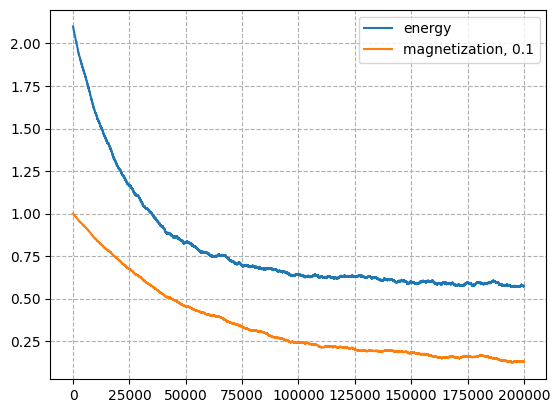

In [239]:
ising = IsingModel(128, 4)
ising.iter_monte_carlo(200000)

energy = -ising.energy/ising.L**2
magnetization = ising.magnetization

X = np.arange(len(ising.energy))
plt.plot(X, energy, label="energy")
plt.plot(X, magnetization, label=f"magnetization, {h}")
plt.legend()
plt.grid(True, ls="--")
plt.show()